# 📊 Visualisation du Benchmark — Prédiction Usure Outil CNC
**Charge `benchmark_results.json`** produit par `benchmark_tool_wear.py` et génère tous les graphes pertinents.

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings; warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────────────────────────
RESULTS_PATH = 'benchmark_results.json'   # ← Modifier si besoin

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

# ── Palette modèles ─────────────────────────────────────────────────────────
MODEL_COLORS = [
    '#1565C0','#E65100','#2E7D32','#6A1B9A','#C62828',
    '#00838F','#F57F17','#4E342E','#37474F','#880E4F',
]

print('✅ Imports OK')

✅ Imports OK


In [10]:
# ── Chargement du JSON ───────────────────────────────────────────────────────
with open(RESULTS_PATH) as f:
    data = json.load(f)

meta        = data['meta']
metrics_raw = data['metrics']
preds_raw   = data['predictions']
TASK        = meta['task']

# Noms courts sans préfixe numérique
def short(name): return name.split('_', 1)[1]

MODEL_NAMES  = [short(k) for k in metrics_raw.keys()]
MODEL_KEYS   = list(metrics_raw.keys())
color_map    = {short(k): MODEL_COLORS[i % len(MODEL_COLORS)]
                for i, k in enumerate(MODEL_KEYS)}

# DataFrame métriques
rows = []
for k, m in metrics_raw.items():
    row = {'model': short(k), **m}
    rows.append(row)
df_m = pd.DataFrame(rows)
df_m = df_m[df_m['status'] == 'ok'].copy()

print(f"Dataset    : {meta['dataset_name']}")
print(f"Tâche      : {TASK.upper()}")
print(f"Cible      : {meta['target_column']}")
print(f"Features   : {meta['features']}")
print(f"Échantill. : {meta['n_samples']}")
print(f"CV Folds   : {meta['cv_folds']}")
print(f"Modèles OK : {len(df_m)}/10")
display(df_m)

Dataset    : phm2010_features.csv
Tâche      : CLASSIFICATION
Cible      : etat
Features   : ['force_x_mean', 'force_x_std', 'force_x_rms', 'force_x_max', 'force_x_p2p', 'force_x_skew', 'force_x_kurt', 'force_x_crest', 'force_x_shape', 'force_x_energy', 'force_x_p25', 'force_x_p75', 'force_x_iqr', 'force_y_mean', 'force_y_std', 'force_y_rms', 'force_y_max', 'force_y_p2p', 'force_y_skew', 'force_y_kurt', 'force_y_crest', 'force_y_shape', 'force_y_energy', 'force_y_p25', 'force_y_p75', 'force_y_iqr', 'force_z_mean', 'force_z_std', 'force_z_rms', 'force_z_max', 'force_z_p2p', 'force_z_skew', 'force_z_kurt', 'force_z_crest', 'force_z_shape', 'force_z_energy', 'force_z_p25', 'force_z_p75', 'force_z_iqr', 'vib_x_mean', 'vib_x_std', 'vib_x_rms', 'vib_x_max', 'vib_x_p2p', 'vib_x_skew', 'vib_x_kurt', 'vib_x_crest', 'vib_x_shape', 'vib_x_energy', 'vib_x_p25', 'vib_x_p75', 'vib_x_iqr', 'vib_y_mean', 'vib_y_std', 'vib_y_rms', 'vib_y_max', 'vib_y_p2p', 'vib_y_skew', 'vib_y_kurt', 'vib_y_crest', 'vi

,model,accuracy,accuracy_std,balanced_accuracy,f1_macro,f1_macro_std,f1_weighted,fit_time_s,status
0,RandomForest,0.9905,0.0013,0.3333,0.3317,0.0002,0.9857,1.02,ok
1,ExtraTrees,0.9905,0.0013,0.3333,0.3317,0.0002,0.9857,0.79,ok
2,GradientBoosting,0.9889,0.0039,0.3328,0.3315,0.0007,0.9849,56.85,ok
3,HistGradientBoosting,0.9910,0.0013,0.3556,0.3652,0.0668,0.9868,3.56,ok
4,Bagging,0.9905,0.0027,0.3665,0.3762,0.0892,0.9864,3.83,ok
5,SVM,0.9910,0.0013,0.3887,0.3986,0.0817,0.9876,0.18,ok
6,KNN,0.9905,0.0013,0.3333,0.3317,0.0002,0.9857,0.17,ok
7,DecisionTree,0.9847,0.0039,0.3314,0.3308,0.0007,0.9828,0.32,ok
8,LogisticRegression,0.9921,0.0017,0.4554,0.4988,0.0862,0.9900,0.12,ok
9,MLP,0.9905,0.0013,0.3333,0.3317,0.0002,0.9857,0.56,ok


---
## 1. 📊 Comparaison des scores (Bar Chart)

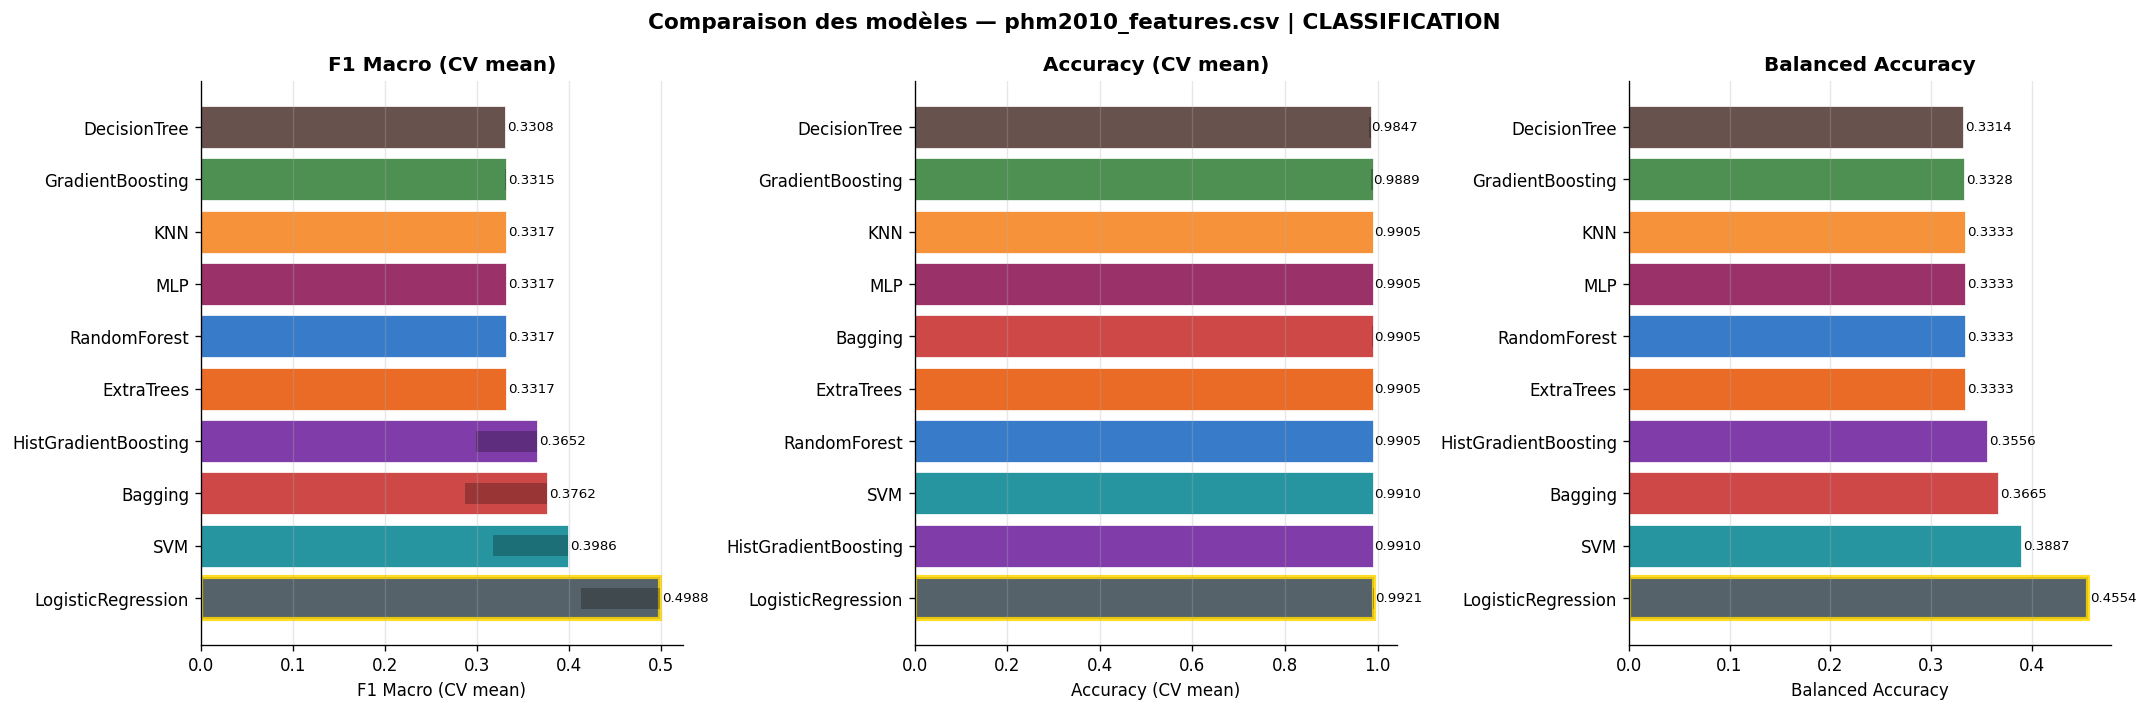

✅ fig1_scores_comparison.png


In [11]:
if TASK == 'classification':
    metrics_to_plot = [
        ('f1_macro',          'f1_macro_std' if 'f1_macro_std' in df_m else None, 'F1 Macro (CV mean)'),
        ('accuracy',          'accuracy_std',                                      'Accuracy (CV mean)'),
        ('balanced_accuracy', None,                                                'Balanced Accuracy'),
    ]
else:
    metrics_to_plot = [
        ('r2',   'r2_std',  'R² (CV mean)'),
        ('mae',  None,      'MAE (CV mean)'),
        ('rmse', None,      'RMSE (CV mean)'),
    ]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 6))
if len(metrics_to_plot) == 1: axes = [axes]

for ax, (metric, err_col, label) in zip(axes, metrics_to_plot):
    if metric not in df_m.columns: continue
    df_sorted = df_m.sort_values(metric, ascending=(metric in ['mae', 'rmse']))
    colors    = [color_map.get(m, 'steelblue') for m in df_sorted['model']]
    bars      = ax.barh(df_sorted['model'], df_sorted[metric], color=colors,
                         alpha=0.85, edgecolor='white', linewidth=0.5)

    if err_col and err_col in df_sorted.columns:
        ax.barh(df_sorted['model'], df_sorted[err_col],
                left=df_sorted[metric] - df_sorted[err_col],
                color='black', alpha=0.25, height=0.4)

    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.grid(True, alpha=0.3, axis='x')
    # Meilleur modèle souligné
    best_val = df_sorted[metric].max() if metric not in ['mae', 'rmse'] else df_sorted[metric].min()
    best_idx = (df_sorted[metric] == best_val).values.argmax()
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)

plt.suptitle(f'Comparaison des modèles — {meta["dataset_name"]} | {TASK.upper()}',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ fig1_scores_comparison.png')

---
## 2. ⏱️ Score vs Temps d'entraînement

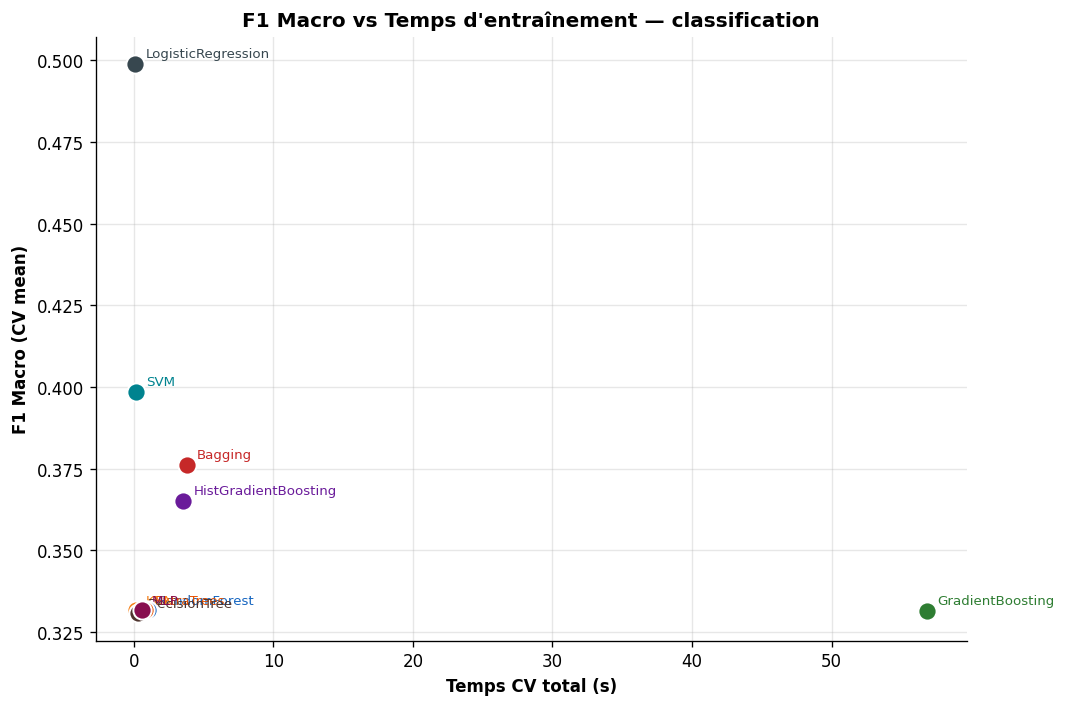

✅ fig2_score_vs_time.png


In [12]:
main_metric = 'f1_macro' if TASK == 'classification' else 'r2'
metric_label = 'F1 Macro' if TASK == 'classification' else 'R²'

fig, ax = plt.subplots(figsize=(9, 6))

for _, row in df_m.iterrows():
    if main_metric not in row or 'fit_time_s' not in row: continue
    c = color_map.get(row['model'], 'steelblue')
    ax.scatter(row['fit_time_s'], row[main_metric], color=c, s=120, zorder=5,
               edgecolors='white', linewidth=1.2)
    ax.annotate(row['model'], (row['fit_time_s'], row[main_metric]),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color=c)

ax.set_xlabel('Temps CV total (s)', fontweight='bold')
ax.set_ylabel(f'{metric_label} (CV mean)', fontweight='bold')
ax.set_title(f'{metric_label} vs Temps d\'entraînement — {TASK}',
              fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✅ fig2_score_vs_time.png')

---
## 3. 🎯 Predicted vs Actual (tous les modèles)

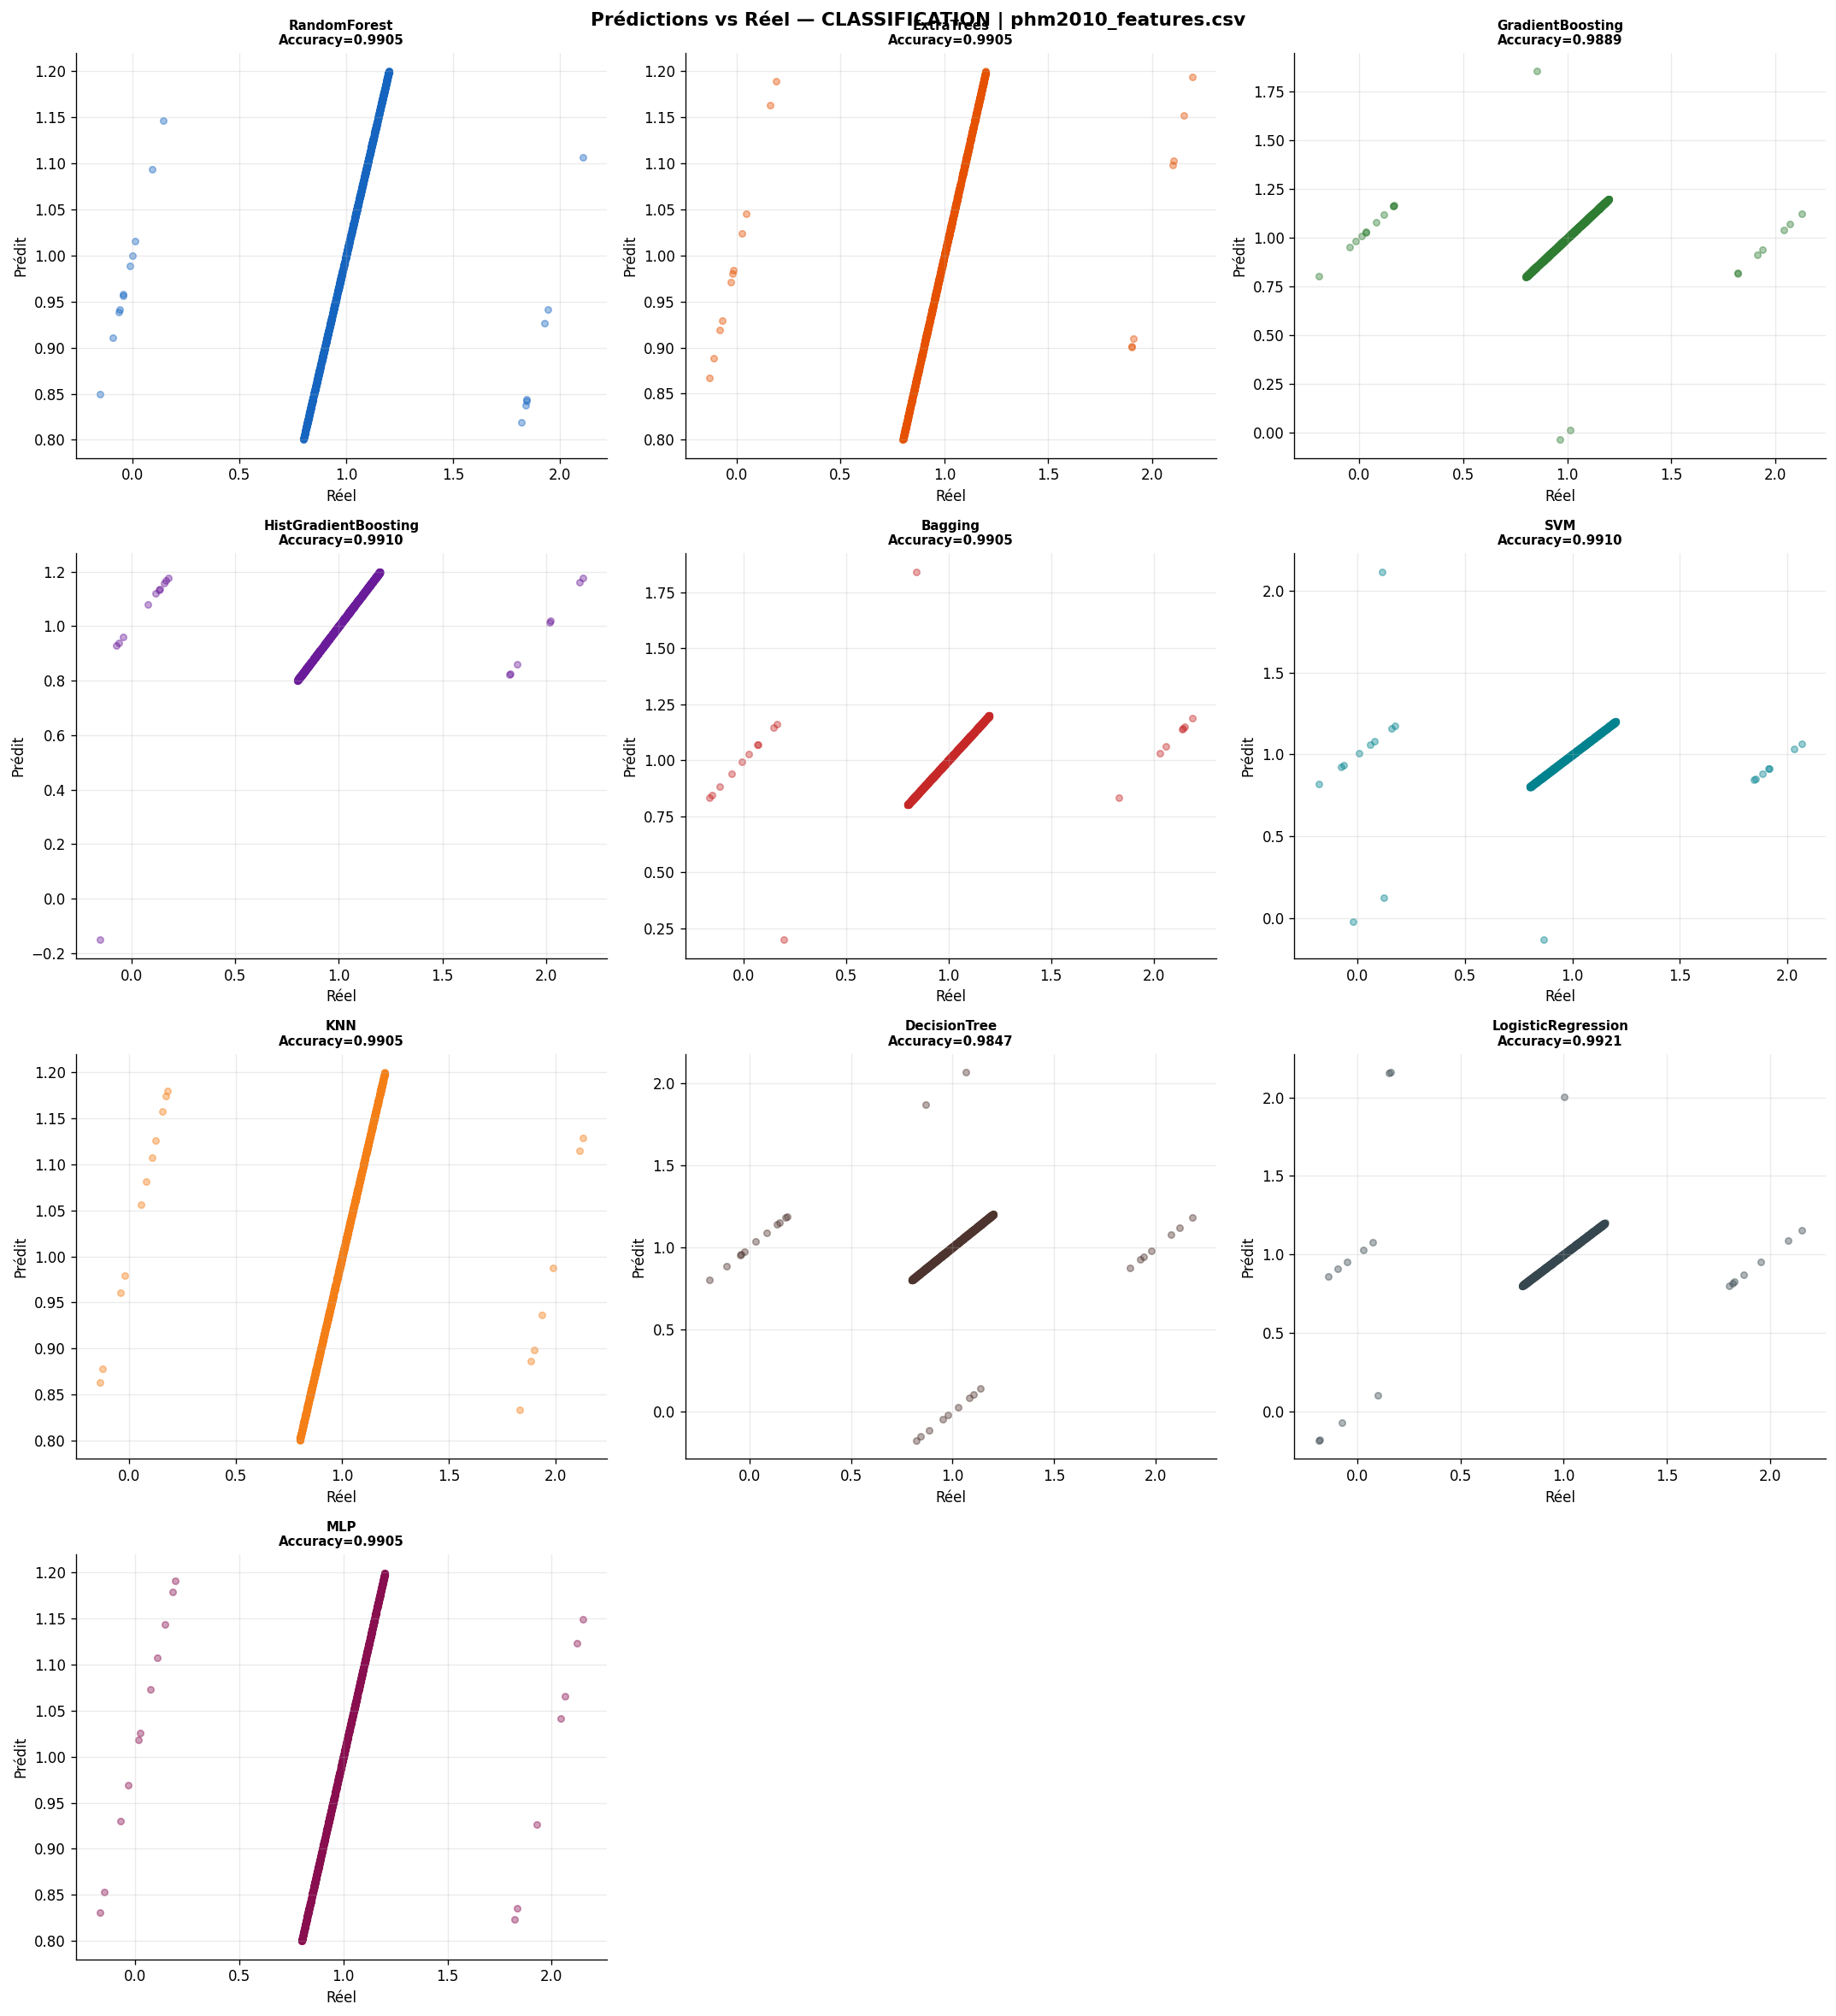

✅ fig3_pred_vs_actual.png


In [13]:
valid_preds = {k: v for k, v in preds_raw.items() if 'y_true' in v and 'y_pred' in v}

n_models  = len(valid_preds)
n_cols    = min(3, n_models)
n_rows    = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, (key, pred) in enumerate(valid_preds.items()):
    ax   = axes_flat[i]
    name = short(key)
    c    = color_map.get(name, 'steelblue')

    y_true = np.array(pred['y_true'])
    y_pred = np.array(pred['y_pred'])

    if TASK == 'regression':
        ax.scatter(y_true, y_pred, alpha=0.5, s=25, color=c,
                   edgecolors='white', linewidth=0.4)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', linewidth=1.2, label='Parfait')
        r2  = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        ax.set_title(f'{name}\nR²={r2:.4f} | MAE={mae:.4f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Réel'); ax.set_ylabel('Prédit')
        ax.text(0.04, 0.92, f'R²={r2:.3f}', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=9)
    else:
        # Scatter avec jitter pour la classification
        jitter = np.random.uniform(-0.2, 0.2, size=len(y_true))
        try:
            y_t_num = y_true.astype(float) + jitter
            y_p_num = y_pred.astype(float) + jitter
        except:
            unique_vals = sorted(set(y_true) | set(y_pred))
            val2num = {v: j for j, v in enumerate(unique_vals)}
            y_t_num = np.array([val2num[v] for v in y_true], float) + jitter
            y_p_num = np.array([val2num[v] for v in y_pred], float) + jitter
        ax.scatter(y_t_num, y_p_num, alpha=0.4, s=20, color=c)
        acc = np.mean(y_true == y_pred)
        ax.set_title(f'{name}\nAccuracy={acc:.4f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Réel'); ax.set_ylabel('Prédit')

    ax.grid(True, alpha=0.25)

for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)

plt.suptitle(f'Prédictions vs Réel — {TASK.upper()} | {meta["dataset_name"]}',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ fig3_pred_vs_actual.png')

---
## 5. 🔴 Matrice de confusion (Classification) / Résidus (Régression)

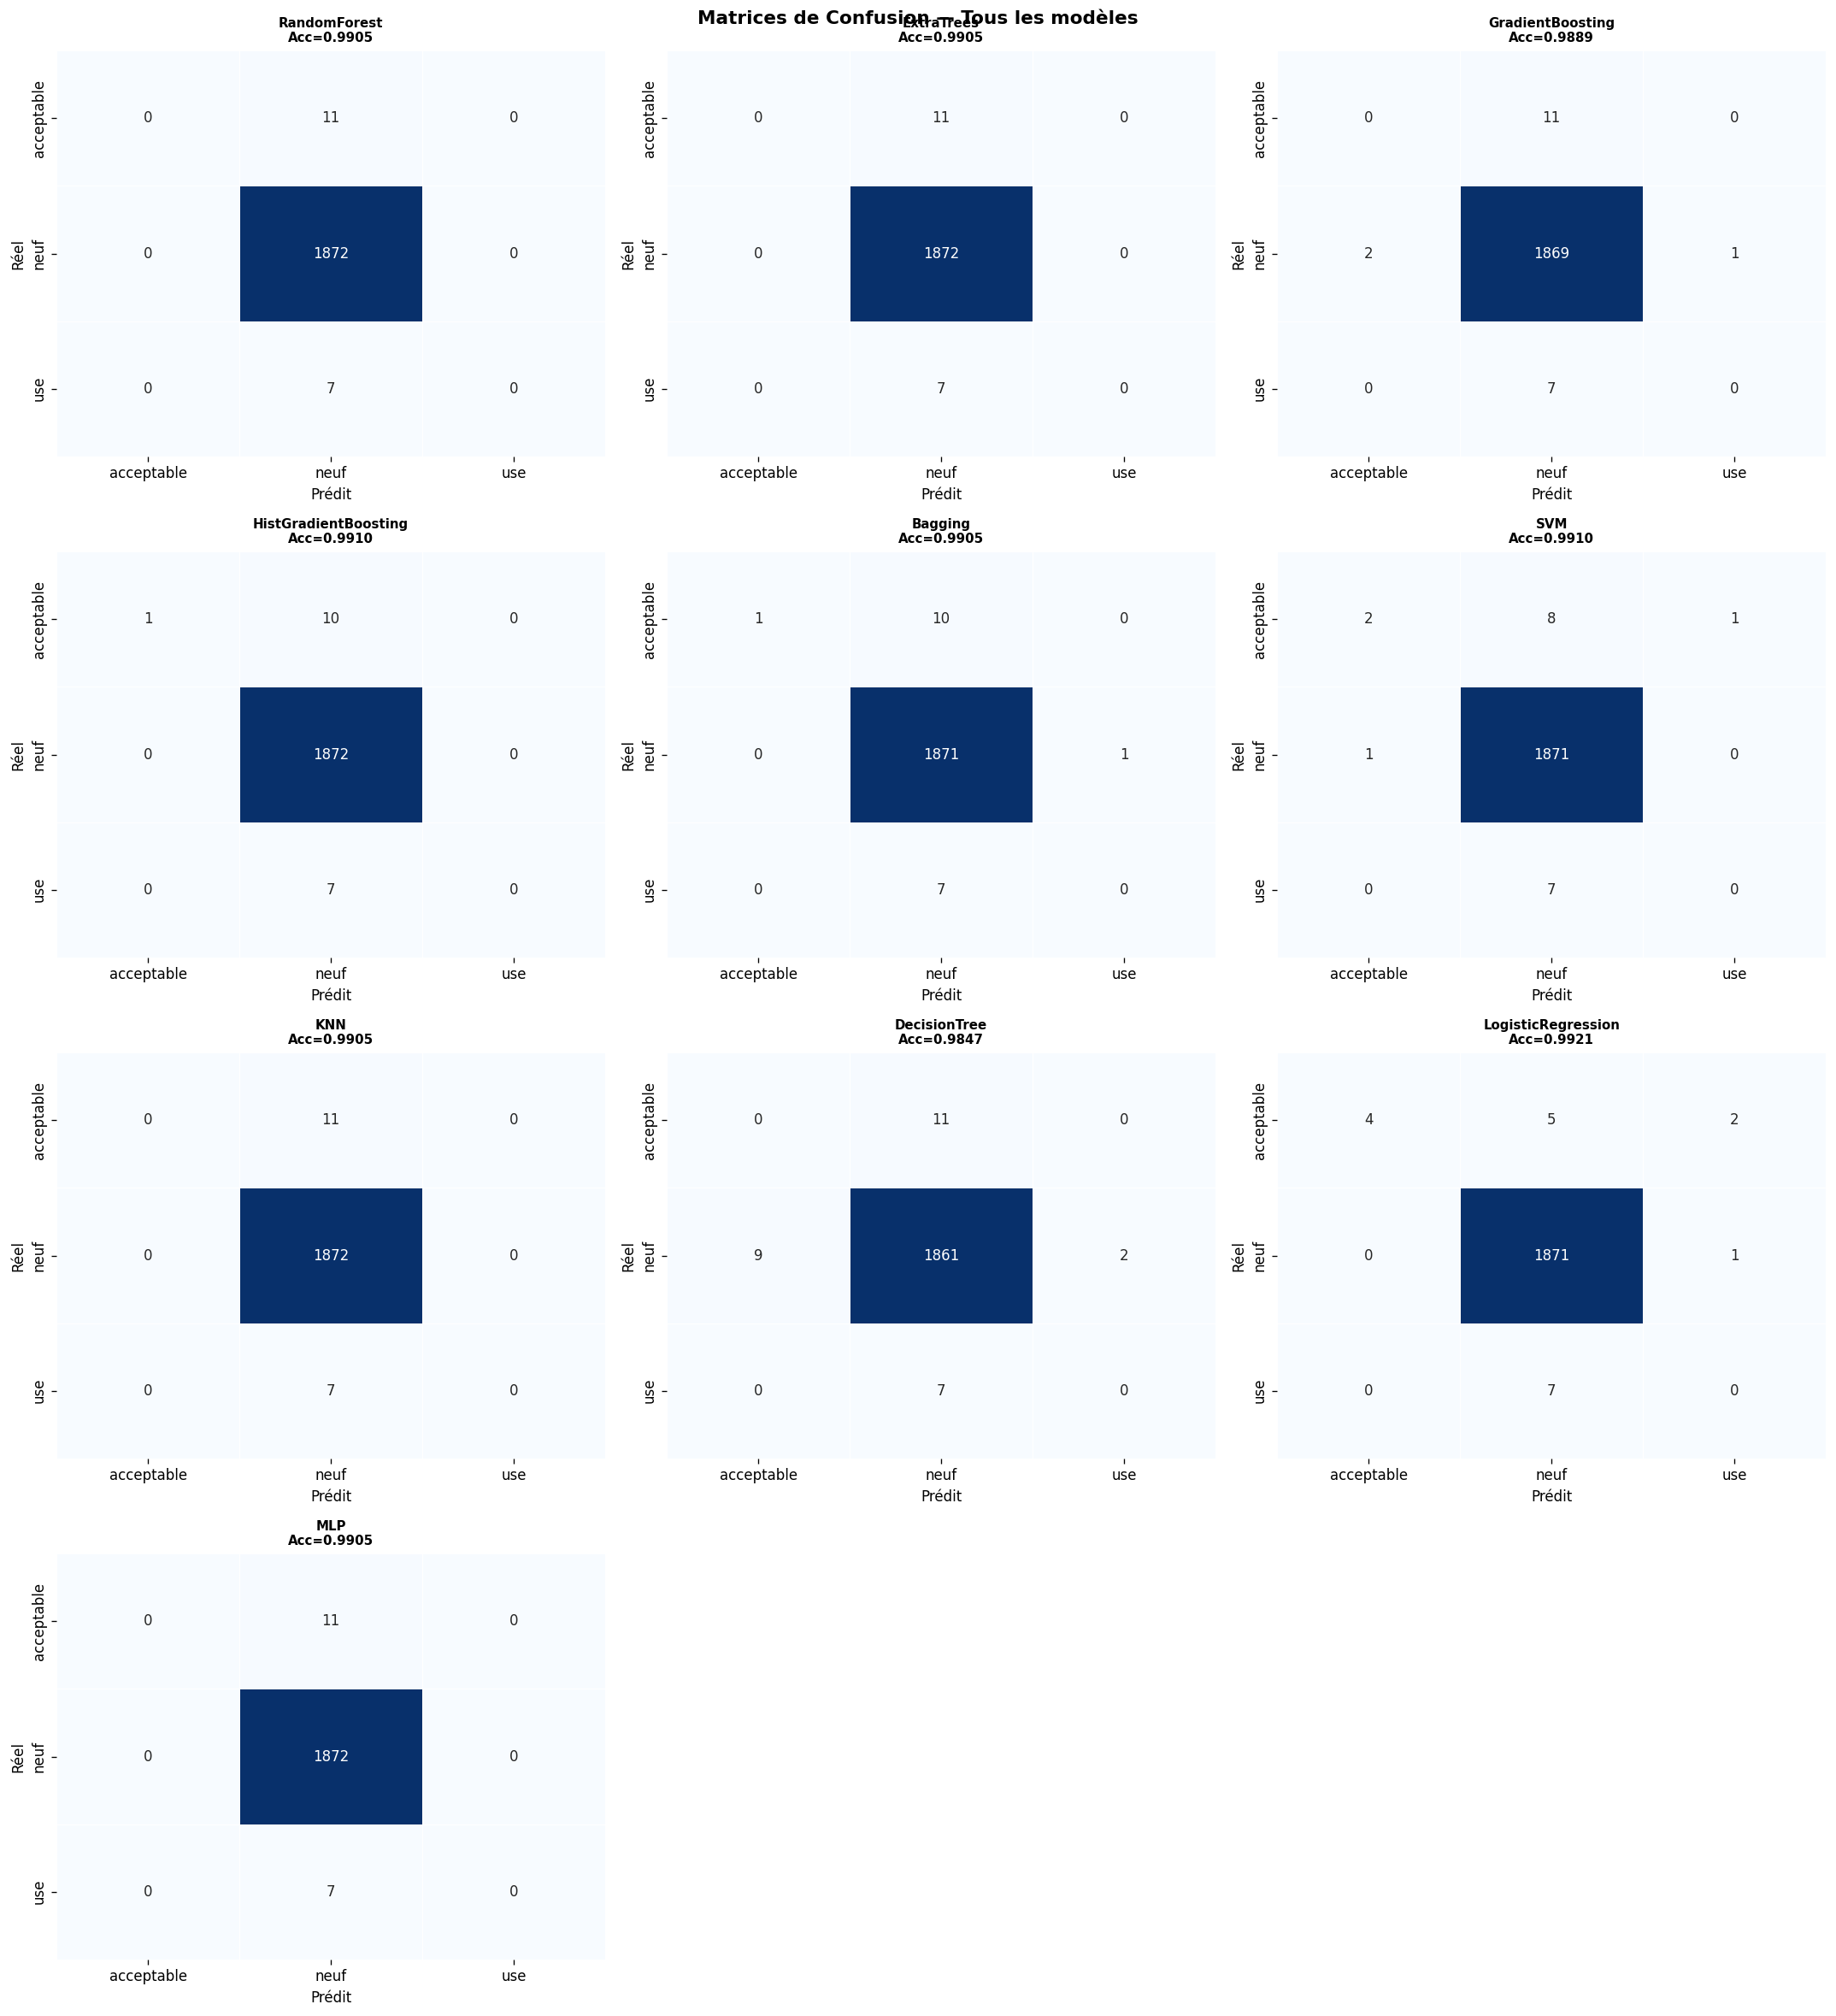

✅ fig5_confusion_or_residuals.png


In [14]:
valid_preds = {k: v for k, v in preds_raw.items() if 'y_true' in v and 'y_pred' in v}

if TASK == 'classification':
    # ── Matrices de confusion ─────────────────────────────────────────────
    n_models = len(valid_preds)
    n_cols   = min(3, n_models)
    n_rows   = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, (key, pred) in enumerate(valid_preds.items()):
        ax   = axes_flat[i]
        name = short(key)
        y_true, y_pred = np.array(pred['y_true']), np.array(pred['y_pred'])
        cm = confusion_matrix(y_true, y_pred)
        classes = pred.get('classes', sorted(set(y_true)))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=classes, yticklabels=classes,
                    cbar=False, linewidths=0.5)
        acc = np.mean(y_true == y_pred)
        ax.set_title(f'{name}\nAcc={acc:.4f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')

    for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)
    plt.suptitle('Matrices de Confusion — Tous les modèles', fontsize=13, fontweight='bold')

else:
    # ── Graphes de résidus ────────────────────────────────────────────────
    n_models = len(valid_preds)
    n_cols   = min(3, n_models)
    n_rows   = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, (key, pred) in enumerate(valid_preds.items()):
        ax   = axes_flat[i]
        name = short(key)
        c    = color_map.get(name, 'steelblue')
        y_true = np.array(pred['y_true'], dtype=float)
        y_pred = np.array(pred['y_pred'], dtype=float)
        residuals = y_true - y_pred
        ax.scatter(y_pred, residuals, alpha=0.5, s=25, color=c, edgecolors='white', linewidth=0.3)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
        rmse = np.sqrt(np.mean(residuals ** 2))
        ax.set_title(f'{name}\nRMSE={rmse:.4f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Valeur prédite'); ax.set_ylabel('Résidu')
        ax.grid(True, alpha=0.25)

    for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)
    plt.suptitle('Graphes de Résidus — Tous les modèles', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('✅ fig5_confusion_or_residuals.png')